# IS 4487 Assignment 11: Predicting Airbnb Prices with Regression

In this assignment, you will:
- Load the Airbnb dataset you cleaned and transformed in Assignment 7
- Build a linear regression model to predict listing price
- Interpret which features most affect price
- Try to improve your model using only the most impactful predictors
- Practice explaining your findings to a business audience like a host, pricing strategist, or city partner

## Why This Matters

Pricing is one of the most important levers for hosts and Airbnb’s business teams. Understanding what drives price — and being able to predict it accurately — helps improve search results, revenue management, and guest satisfaction.

This assignment gives you hands-on practice turning a cleaned dataset into a predictive model. You’ll focus not just on code, but on what the results mean and how you’d communicate them to stakeholders.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load Your Transformed Airbnb Dataset

**Business framing:**  
Before building any models, we must start with clean, prepared data. In Assignment 7, you exported a cleaned version of your Airbnb dataset. You’ll now import that file for analysis.

### Do the following:
- Import your CSV file called `cleaned_airbnb_data_7.csv`.   (Note: If you had significant errors with assignment 7, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)
- Use `pandas` to load and preview the dataset

### In Your Response:
1. What does the dataset include?
2. How many rows and columns are present?


In [2]:
df = pd.read_csv('cleaned_airbnb_data_7.csv')

display(df.head())

print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,reviews_per_month_filled,reviews_per_month_category,no_rentals_30_days_plus,price_above_average_flag,price_above_average,host_response_time_within an hour,host_response_time_within a few hours,host_response_time_within a day,host_response_time_a few days or more,host_response_time_Unknown
0,42515,https://www.airbnb.com/rooms/42515,20250928035237,2025-09-28,city scrape,Geneva center - Hosting females,NaN,NaN,https://a0.muscache.com/pictures/10640277/ff1d...,185647,...,0.48,High,False,False,False,False,False,True,False,False
1,203997,https://www.airbnb.com/rooms/203997,20250928035237,2025-09-28,city scrape,Top location studio 1 block from lake!,"Spacious studio with washer/dryer, Wi-fi, supe...",This is the most sought after area in Geneva: ...,https://a0.muscache.com/pictures/14163740/9392...,1001280,...,0.62,High,False,False,False,True,False,False,False,False
2,276025,https://www.airbnb.com/rooms/276025,20250928035237,2025-09-28,city scrape,Lovely flat by Geneva lake,This cozy flat is located in a very pleasant v...,"Versoix is a pretty fishing village, on the ed...",https://a0.muscache.com/pictures/4156456/d3aed...,1442438,...,0.75,High,False,False,False,True,False,False,False,False
3,338682,https://www.airbnb.com/rooms/338682,20250928035237,2025-09-28,previous scrape,Top location 1 block from the lake!,One bedroom apartment located in a pedestrian ...,This is the favourite area for expats in Genev...,https://a0.muscache.com/pictures/14164129/db92...,1001280,...,0.79,High,False,False,False,True,False,False,False,False
4,399388,https://www.airbnb.com/rooms/399388,20250928035237,2025-09-28,city scrape,Nice modern bedroom with balcony,Unwind in this modern private bedroom with a c...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1994454,...,0.38,High,False,False,False,False,True,False,False,False


The dataset has 2719 rows and 92 columns.


### ✍️ Your Response: 🔧
1. My data set as many binary and non-ordinal numeric columns such as listing ID, date, etc

2. In total there are currently 2719 rows and 92 columns

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
Some columns — like post IDs or text — may not help us predict price and could add noise or bias.

### Do the following:
- Drop columns like `post_id`, `title`, `descr`, `details`, and `address` if they’re still in your dataset

### In Your Response:
1. What columns did you drop, and why?
2. What risks might occur if you included them in your model?


In [3]:
# List of columns to drop based on common practice for identifiers, text, and dates
columns_to_drop = [
    'id', 'listing_url', 'name', 'description', 'host_name', 'host_url',
    'host_about', 'neighborhood_overview', 'host_location',
    'last_scraped', 'calendar_last_scraped', 'first_review', 'last_review',
    'bathrooms_text']

object_columns = df.select_dtypes(include='object').columns.tolist()
all_columns_to_drop = list(set(columns_to_drop + object_columns))
if 'price' in all_columns_to_drop:
    all_columns_to_drop.remove('price')
existing_columns_to_drop = [col for col in all_columns_to_drop if col in df.columns]
df = df.drop(columns=existing_columns_to_drop, errors='ignore')
print(f"Columns dropped: {existing_columns_to_drop}")
print(f"New dataset shape: {df.shape}")

display(df.head())

Columns dropped: ['host_acceptance_rate', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'picture_url', 'reviews_per_month_category', 'host_thumbnail_url', 'description', 'room_type', 'property_type', 'host_url', 'host_verifications', 'host_picture_url', 'host_response_rate', 'name', 'license', 'neighbourhood_cleansed', 'host_since', 'calendar_last_scraped', 'host_is_superhost', 'last_review', 'listing_url', 'bedrooms_binned', 'host_about', 'source', 'entire_home', 'instant_bookable', 'id', 'neighborhood_overview', 'last_scraped', 'bathrooms_text', 'first_review', 'host_name', 'host_location', 'amenities']
New dataset shape: (2719, 57)


,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_value_zscore,reviews_per_month_filled,no_rentals_30_days_plus,price_above_average_flag,price_above_average,host_response_time_within an hour,host_response_time_within a few hours,host_response_time_within a day,host_response_time_a few days or more,host_response_time_Unknown
0,20250928035237,185647,1,1,46.20198,6.15672,1,1.5,1.0,1.0,...,-0.151678,0.48,False,False,False,False,False,True,False,False
1,20250928035237,1001280,7,13,46.19964,6.15580,2,1.0,1.0,0.0,...,0.437083,0.62,False,False,False,True,False,False,False,False
2,20250928035237,1442438,2,2,46.28031,6.16833,3,1.0,1.0,4.0,...,0.165347,0.75,False,False,False,True,False,False,False,False
3,20250928035237,1001280,7,13,46.20708,6.15545,2,NaN,1.0,NaN,...,0.233281,0.79,False,False,False,True,False,False,False,False
4,20250928035237,1994454,2,3,46.18904,6.13908,2,1.0,1.0,1.0,...,0.233281,0.38,False,False,False,False,True,False,False,False


### ✍️ Your Response: 🔧
1. I dropped as many columns as possible that had text or irrelevant numeric numbers. These would include ID, dates, review dates, name, listing ID and URL.

2. One risk that might occur is that the model may assume listing ID or some other nominal variable is ordinal when it is not, which could create misrepresentative coefficients, R square and MSE.
Another risk of having too many nominal or irrelavent data is that it creates a lot of statistical noise that can dilute the actual effectivness and accuracy of the model

## 3. Explore Relationships Between Numeric Features

**Business framing:**  
Understanding how features relate to each other — and to the target — helps guide feature selection and modeling.

### Do the following:
- Generate a correlation matrix
- Identify which variables are strongly related to `price`

### In Your Response:
1. Which variables had the strongest positive or negative correlation with price?
2. Which variables might be useful predictors?


Correlation with price (top 10 positive and top 5 negative):
price                       1.000000
bathrooms                   0.336312
accommodates                0.254778
accommodates_minmax         0.254778
price_above_average_flag    0.221367
price_above_average         0.221367
beds                        0.207538
bedrooms                    0.194232
bedrooms_log                0.173711
latitude                    0.084850
availability_30             0.069330
Name: price, dtype: float64
review_scores_value        -0.052650
reviews_per_month          -0.058647
reviews_per_month_scaled   -0.058647
scrape_id                        NaN
calendar_updated                 NaN
Name: price, dtype: float64


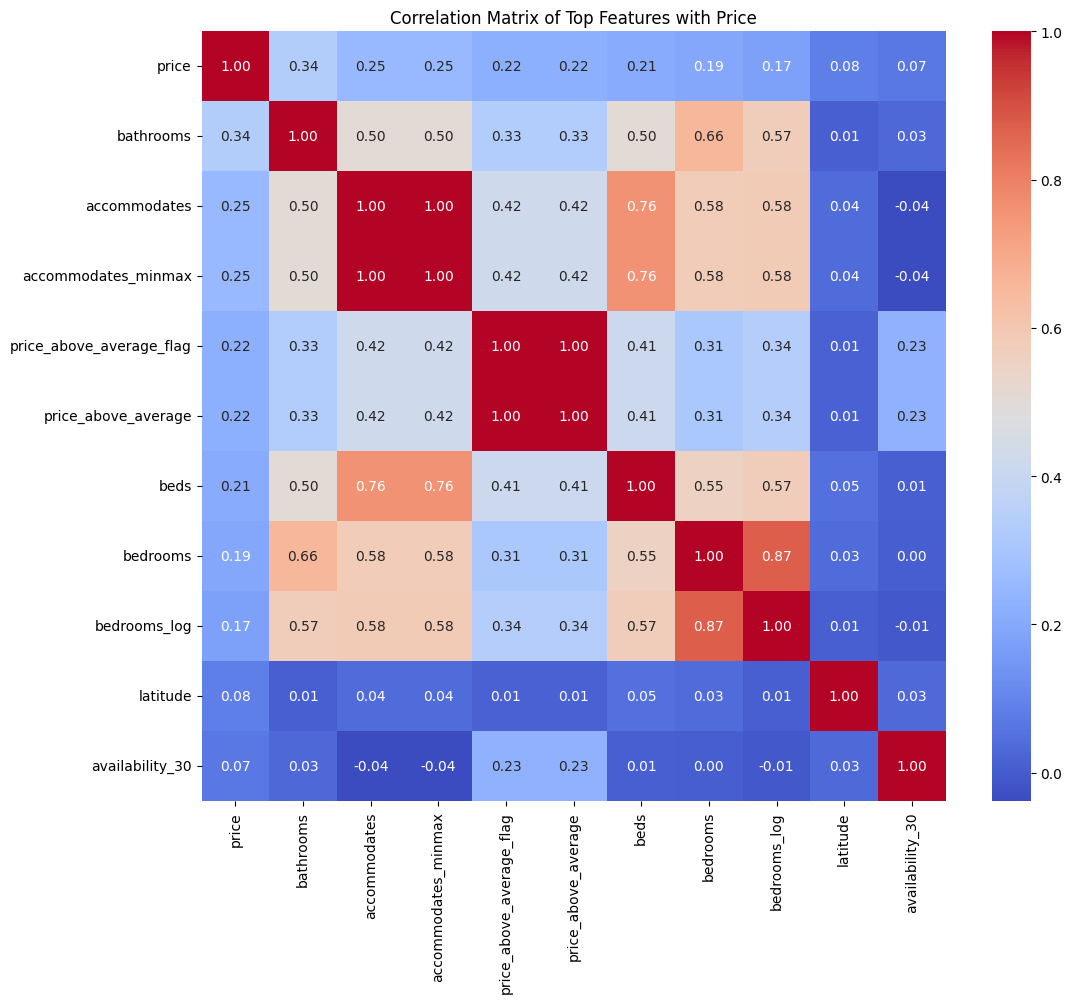

In [8]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display correlations with 'price' in descending order
price_correlations = correlation_matrix['price'].sort_values(ascending=False)

print("Correlation with price (top 10 positive and top 5 negative):")
print(price_correlations.head(11)) # price itself + top 10 positive
print(price_correlations.tail(5)) # top 5 negative

# Visualize the correlations with a heatmap for the top N features (optional, but good for exploration)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix.loc[price_correlations.head(11).index, price_correlations.head(11).index], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top Features with Price')
plt.show()

### ✍️ Your Response: 🔧
1. To my suprise none of the variables had a particularly strong correlation with price, the strongest being baths at a 0.34. There were also noticable positive correlations between accomodates and bedrooms.

2. Based on the correlation matrix the bedrooms and accomodates seems to be the best predictor for price.

## 4. Define Features and Target Variable

**Business framing:**  
To build a regression model, you need to define what you’re predicting (target) and what you’re using to make that prediction (features).

### Do the following:
- Set `price` as your target variable
- Remove `price` from your predictors

### In Your Response:
1. What features are you using?
2. Why is this a regression problem and not a classification problem?


In [42]:
selected_features = ['beds', 'bedrooms', 'bathrooms', 'accommodates', 'availability_30', 'availability_60', 'availability_90', 'availability_365']
y = df['price']
X = df[selected_features]

# Ensure only numeric columns are used and handle NaNs consistently
X = X.select_dtypes(include=['number'])
combined = pd.concat([X, y], axis=1).dropna()
X = combined[X.columns]
y = combined['price']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Features used: {X.columns.tolist()}")
df.head()

Features (X) shape: (2046, 8)
Target (y) shape: (2046,)
Features used: ['beds', 'bedrooms', 'bathrooms', 'accommodates', 'availability_30', 'availability_60', 'availability_90', 'availability_365']


,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_value_zscore,reviews_per_month_filled,no_rentals_30_days_plus,price_above_average_flag,price_above_average,host_response_time_within an hour,host_response_time_within a few hours,host_response_time_within a day,host_response_time_a few days or more,host_response_time_Unknown
0,20250928035237,185647,1,1,46.20198,6.15672,1,1.5,1.0,1.0,...,-0.151678,0.48,False,False,False,False,False,True,False,False
1,20250928035237,1001280,7,13,46.19964,6.15580,2,1.0,1.0,0.0,...,0.437083,0.62,False,False,False,True,False,False,False,False
2,20250928035237,1442438,2,2,46.28031,6.16833,3,1.0,1.0,4.0,...,0.165347,0.75,False,False,False,True,False,False,False,False
3,20250928035237,1001280,7,13,46.20708,6.15545,2,NaN,1.0,NaN,...,0.233281,0.79,False,False,False,True,False,False,False,False
4,20250928035237,1994454,2,3,46.18904,6.13908,2,1.0,1.0,1.0,...,0.233281,0.38,False,False,False,False,True,False,False,False


### ✍️ Your Response: 🔧
1. I decided to use the top 10 most correlative features to price as the features for my model

2. Since we are trying to predict price and how much a certain variable impacts price we are doing regression rather than classification since regression yields coefficeints that will tell us how much one features impacts the target variable.

## 5. Split Data into Training and Testing Sets

### Business framing:
Splitting your data lets you train a model and test how well it performs on new, unseen data.

### Do the following:
- Use `train_test_split()` to split into 80% training, 20% testing



In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1636, 8)
X_test shape: (410, 8)
y_train shape: (1636,)
y_test shape: (410,)


## 6. Fit a Linear Regression Model

### Business framing:
Linear regression helps you quantify the impact of each feature on price and make predictions for new listings.

### Do the following:
- Fit a linear regression model to your training data
- Use it to predict prices for the test set



In [44]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
coefficients = pd.Series(model.coef_, index=X_train.columns)
print(coefficients.sort_values(ascending=False))

bathrooms           313.897234
accommodates         99.957824
availability_30       4.201018
availability_90       1.667140
availability_365     -0.244297
availability_60      -2.363389
bedrooms            -15.865623
beds                -64.482060
dtype: float64


## 7. Evaluate Model Performance

### Business framing:  
A good model should make accurate predictions. We’ll use Mean Squared Error (MSE) and R² to evaluate how close our predictions were to the actual prices.

### Do the following:
- Print MSE and R² score for your model

### In Your Response:
1. What is your R² score? How well does your model explain price variation?
2. Is your MSE large or small? What could you do to improve it?


In [48]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 32679.71
R-squared (R²): -1.39


### ✍️ Your Response: 🔧
1. The R square score was a -1.39, indicating a very poor explaination for the price based on the used features.

2. The MSE is 32679, indication A high degree of variation and innacuraccy using the selected features as a predictor for the price

## 8. Interpret Model Coefficients

### Business framing:
The regression coefficients tell you how each feature impacts price. This can help Airbnb guide hosts and partners.

### Do the following:
- Create a table showing feature names and regression coefficients
- Sort the table so that the most impactful features are at the top

### In Your Response:
1. Which features increased price the most?
2. Were any surprisingly negative?
3. What business insight could you draw from this?


In [49]:
coefficients_df = coefficients.abs().sort_values(ascending=False).to_frame(name='Absolute Coefficient Value')
coefficients_df['Original Coefficient'] = coefficients

display(coefficients_df)

,Absolute Coefficient Value,Original Coefficient
bathrooms,313.897234,313.897234
accommodates,99.957824,99.957824
beds,64.482060,-64.482060
bedrooms,15.865623,-15.865623
availability_30,4.201018,4.201018
availability_60,2.363389,-2.363389
availability_90,1.667140,1.667140
availability_365,0.244297,-0.244297


### ✍️ Your Response: 🔧
1. Bathrooms by far had the most impact on price, this could be because typically there are only 1 bathrooms to 3 or 4 at most so because the range is so narrow any increase will reflect in large price differences.

2.the number of beds and bedrooms seems to have an inverse relationship with price which is not typical of most real estate and properties

3. Since the data is behaving strangely I would be hesitant to make any business infrences off these numbers alone, I would be more comfortable with further investigation to see if there is a missing variable that could better predict the price, such as the location or neighborhoods within the city.

## 9. Try to Improve the Linear Regression Model

### Business framing:
The first version of your model included all available features — but not all features are equally useful. Removing weak or noisy predictors can often improve performance and interpretation.

### Do the following:
1. Choose your top 3–5 features with the strongest absolute coefficients
2. Rebuild the regression model using just those features
3. Compare MSE and R² between the baseline and refined model

### In Your Response:
1. What features did you keep in the refined model, and why?
2. Did model performance improve? Why or why not?
3. Which model would you recommend to stakeholders?
4. How does this relate to your customized learning outcome you created in canvas?


In [50]:
# Add code here 🔧
selected_features = ['beds', 'bathrooms', 'accommodates',]
X = df[selected_features]

# Ensure only numeric columns are used and handle NaNs consistently
X = X.select_dtypes(include=['number'])
combined = pd.concat([X, y], axis=1).dropna()
X = combined[X.columns]
y = combined['price']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Features used: {X.columns.tolist()}")
df.head()

Features (X) shape: (2046, 3)
Target (y) shape: (2046,)
Features used: ['beds', 'bathrooms', 'accommodates']


,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,...,review_scores_value_zscore,reviews_per_month_filled,no_rentals_30_days_plus,price_above_average_flag,price_above_average,host_response_time_within an hour,host_response_time_within a few hours,host_response_time_within a day,host_response_time_a few days or more,host_response_time_Unknown
0,20250928035237,185647,1,1,46.20198,6.15672,1,1.5,1.0,1.0,...,-0.151678,0.48,False,False,False,False,False,True,False,False
1,20250928035237,1001280,7,13,46.19964,6.15580,2,1.0,1.0,0.0,...,0.437083,0.62,False,False,False,True,False,False,False,False
2,20250928035237,1442438,2,2,46.28031,6.16833,3,1.0,1.0,4.0,...,0.165347,0.75,False,False,False,True,False,False,False,False
3,20250928035237,1001280,7,13,46.20708,6.15545,2,NaN,1.0,NaN,...,0.233281,0.79,False,False,False,True,False,False,False,False
4,20250928035237,1994454,2,3,46.18904,6.13908,2,1.0,1.0,1.0,...,0.233281,0.38,False,False,False,False,True,False,False,False


In [52]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"New Model Mean Squared Error (MSE): {mse:.2f}")
print(f"New Model R-squared (R²): {r2:.2f}")

New Model Mean Squared Error (MSE): 32845.19
New Model R-squared (R²): -1.40


### ✍️ Your Response: 🔧
1. I went with just 3 features to minimize any possible noise, and chose the 3 features with the highest correlation to price.

2. The model did not improve when reducing the features, the R square and MSE were essentially unchanged to the point where the new model could be useful

3. Of the two models, I would reccomend the first as it had a better R square and evaluated more variables.

4. This relates to my learning outcomes becasue statistical analysis was one of my learning outcomes and we got to use R square and MSE and regression for analysis which is a great tool for creating models for data that explain variation and influence.


## 10. Reflect and Recommend

### Business framing:  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to Airbnb or its hosts?
3. What could you do next to improve this model or make it more useful?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. Sicne my model didn't give a very strong result, the biggest business problem this model answered is that there is more investigation and data collection needed before price can be accurately predicted, perhapse neighborhoods or location.

2. I would reccomend to hosts that no single varible has a storng relationship to price, and that other factors or market influences may be the best rational for prices rather than features of a property.

3. I would rexamine some of the dropped columns to see if there is a chance any binary or nominal variables could be converted to ordinal and then incorperated into the model to help find better explaination.

4. This exercise really test the analytics and critical thinking side which was a learning outcome, since I don't have a very strong model, I had to think critically on why that might be and what could be done to the data or model to improve it.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [53]:
!jupyter nbconvert --to html "assignment_11_FugalEric.ipynb"

[NbConvertApp] Converting notebook assignment_11_FugalEric.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 528132 bytes to assignment_11_FugalEric.html
